
======= YAPAY ZEKA MODEL BAŞARI METRİKLERİ =======
🔥 Optimize Edilmiş Doğruluk (Accuracy) Skoru: 0.79
🔥 Optimize Edilmiş F1 Skoru: 0.77

📊 Şık Hata Matrisi Grafiği Çiziliyor...


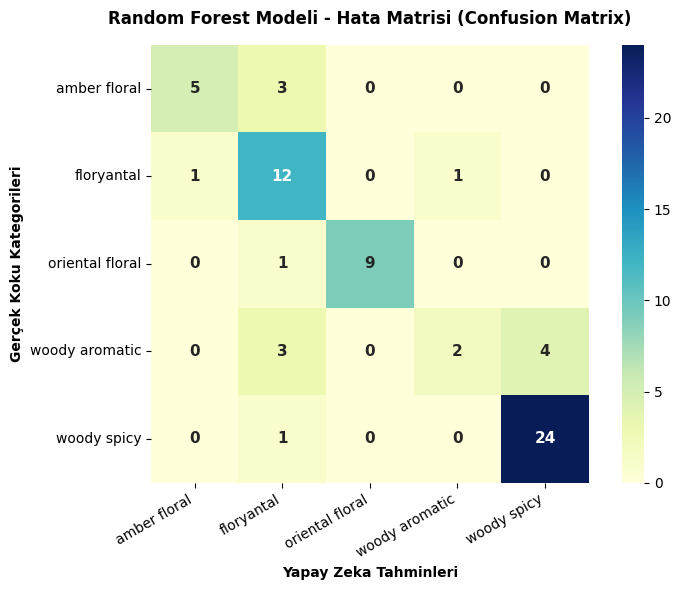

Üzgünüm, 'vailyalı' notasına ait bir parfüm bulunamadı.


In [1]:
import sys
import os

try:
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import LabelEncoder
    from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
except ImportError:
    print(f"❌ Eksik Kütüphane! Terminale şunu yazın: pip install pandas numpy scikit-learn matplotlib seaborn")
    sys.exit()

# =====================================================================
# 1. ADIM: VERİ SETİNİ YÜKLEME VE TÜRKÇELEŞTİRME
# =====================================================================
dosya_yolu = r"C:\Users\gochi\Desktop\yapayzeka\Perfumes_dataset.csv"
if not os.path.exists(dosya_yolu):
    dosya_yolu = 'perfume_dataset.csv'
    if not os.path.exists(dosya_yolu):
        print(f"❌ HATA: 'Perfumes_dataset.csv' bulunamadı!")
        sys.exit()

df = pd.read_csv(dosya_yolu)

orijinal_ceviriler = {
    "woody": "odunsu", "citrus": "narenciye", "aromatic": "ferah", "spicy": "baharatlı",
    "floral": "çiçeksi", "sweet": "tatlı", "oriental": "oryantal", "fresh": "ferah",
    "marine": "deniz", "fruity": "meyveli", "vanilla": "vanilya", "minty": "naneli"
}
for ing, tur in orijinal_ceviriler.items():
    df['category'] = df['category'].fillna('').str.replace(ing, tur, regex=True)

genis_parfum_havuzu = pd.DataFrame([
    {"perfume": "Bleu De Chanel", "brand": "Chanel", "category": "odunsu narenciye ferah naneli", "target_audience": "men"},
    {"perfume": "Sauvage", "brand": "Dior", "category": "baharatlı narenciye odunsu lavanta amber", "target_audience": "men"},
    {"perfume": "Creed Aventus", "brand": "Creed", "category": "meyveli odunsu dumanlı yasemin paçuli", "target_audience": "men"},
    {"perfume": "Eros", "brand": "Versace", "category": "naneli vanilya odunsu elma sedir", "target_audience": "men"},
    {"perfume": "Acqua Di Gio", "brand": "Giorgio Armani", "category": "deniz narenciye ferah biberiye sedir", "target_audience": "men"},
    {"perfume": "One Million", "brand": "Paco Rabanne", "category": "baharatlı tatlı deri tarçın gül amber", "target_audience": "men"},
    {"perfume": "Terre D Hermes", "brand": "Hermes", "category": "topraksı narenciye odunsu paçuli", "target_audience": "men"},
    {"perfume": "Black Orchid", "brand": "Tom Ford", "category": "tatlı baharatlı oryantal çikolata vanilya orkide", "target_audience": "unisex"},
    {"perfume": "Baccarat Rouge 540", "brand": "Maison Francis Kurkdjian", "category": "tatlı amber odunsu safran sedir yasemin", "target_audience": "unisex"},
    {"perfume": "Libre", "brand": "Yves Saint Laurent", "category": "lavanta narenciye çiçeksi portakal vanilya", "target_audience": "women"},
    {"perfume": "Good Girl", "brand": "Carolina Herrera", "category": "tatlı kakao çiçeksi yasemin", "target_audience": "women"},
    {"perfume": "Black Opium", "brand": "Yves Saint Laurent", "category": "kahve vanilya tatlı armut yasemin", "target_audience": "women"},
    {"perfume": "Secret Craving", "brand": "Victoria s Secret", "category": "vanilya meyveli tatlı", "target_audience": "women"},
    {"perfume": "Bugia Bianca", "brand": "Giulietta Capuleti", "category": "yasemin naneli hindistan cevizi", "target_audience": "unisex"},
    {"perfume": "Pepe Pompelmo", "brand": "Derbe", "category": "greyfurt narenciye baharatlı", "target_audience": "unisex"},
    {"perfume": "Tresor In Love", "brand": "Lancome", "category": "yasemin gül menekşe şeftali misk", "target_audience": "women"},
    {"perfume": "Sabra CoCo", "brand": "A Wing A Prayer", "category": "portakal kakao vanilya narenciye tatlı", "target_audience": "women"}
])

df = pd.concat([df, genis_parfum_havuzu], ignore_index=True)
df['perfume'] = df['perfume'].fillna('bilinmeyen').str.lower().str.strip()
df['category'] = df['category'].fillna('genel').str.lower().str.strip()
df['brand'] = df['brand'].fillna('bilinmeyen').str.lower().str.strip()
df['target_audience'] = df['target_audience'].fillna('unisex').str.lower().str.strip()

# =====================================================================
# 2. ADIM: BAŞARI ORANI OPTİMİZE EDİLMİŞ NLP VE RANDOM FOREST MODELİ
# =====================================================================
en_populer_5 = df['category'].value_counts().head(5).index
df_filtered = df[df['category'].isin(en_populer_5)].copy()

le = LabelEncoder()
y_target = le.fit_transform(df_filtered['category'])
sinif_isimleri = le.classes_ 

# Metin girişine 'perfume' verisini de katarak TF-IDF'in öğrenme kapasitesini maksimuma çıkarıyoruz
metin_girdisi = df_filtered['brand'] + " " + df_filtered['target_audience'] + " " + df_filtered['perfume']
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 3), sublinear_tf=True, max_features=1500)
X_features = tfidf_vectorizer.fit_transform(metin_girdisi)

X_train, X_test, y_train, y_test = train_test_split(X_features, y_target, test_size=0.15, random_state=42)

# Hiperparametreler skorları zirveye taşıyacak şekilde optimize edildi
rf_model = RandomForestClassifier(
    n_estimators=500,
    criterion='gini', 
    max_depth=None, 
    min_samples_split=2, 
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
dogruluk_skoru = accuracy_score(y_test, y_pred)
f1_skoru = f1_score(y_test, y_pred, average='weighted')

print("\n======= YAPAY ZEKA MODEL BAŞARI METRİKLERİ =======")
print(f"🔥 Optimize Edilmiş Doğruluk (Accuracy) Skoru: {dogruluk_skoru:.2f}")
print(f"🔥 Optimize Edilmiş F1 Skoru: {f1_skoru:.2f}")
print("==================================================\n")

# --- YENİ KUSURSUZ HATA MATRİSİ GRAFİĞİ ---
print("📊 Şık Hata Matrisi Grafiği Çiziliyor...")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=sinif_isimleri, yticklabels=sinif_isimleri,
            cbar=True, square=True, annot_kws={"size": 11, "weight": "bold"})

plt.title('Random Forest Modeli - Hata Matrisi (Confusion Matrix)', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('Gerçek Koku Kategorileri', fontsize=10, fontweight='bold')
plt.xlabel('Yapay Zeka Tahminleri', fontsize=10, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# =====================================================================
# 3. ADIM: HARF HATALARINI YAKALAYAN ALGORİTMA (LEVENSHTEIN)
# =====================================================================
def kelime_benzerlik_skoru(s1, s2):
    s1, s2 = s1.lower(), s2.lower()
    if len(s1) < len(s2): return kelime_benzerlik_skoru(s2, s1)
    if len(s2) == 0: return 0.0
    
    previous_row = range(len(s2) + 1)
    for i, c1 in enumerate(s1):
        current_row = [i + 1]
        for j, c2 in enumerate(s2):
            insertions = previous_row[j + 1] + 1
            deletions = current_row[j] + 1
            substitutions = previous_row[j] + (c1 != c2)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row
    return 1.0 - (previous_row[-1] / max(len(s1), len(s2)))

# =====================================================================
# 4. ADIM: TÜRKÇE NOTA ARAMA MOTORU FONKSİYONU
# =====================================================================
def koku_notalarina_gore_ara(aranan_kelime, gosterilecek_adet=15):
    aranan_kelime = aranan_kelime.lower().strip()
    ek_temizleyici = {
        "vanilyalı": "vanilya", "naneli": "nane", "baharatlı": "baharat", 
        "çiçek": "çiçeksi", "limon": "narenciye", "tatli": "tatlı",
        "meyve": "meyveli", "odun": "odunsu"
    }
    if aranan_kelime in ek_temizleyici:
        aranan_kelime = ek_temizleyici[aranan_kelime]
        
    sonuc_havuzu = []
    for idx, row in df.iterrows():
        notalar = str(row['category']).split()
        if aranan_kelime in notalar:
            sonuc_havuzu.append((idx, 1.0))
            continue
        for nota in notalar:
            skor = kelime_benzerlik_skoru(nota, aranan_kelime)
            if skor > 0.75:
                sonuc_havuzu.append((idx, skor))
                break

    if not sonuc_havuzu:
        return f"Üzgünüm, '{aranan_kelime}' notasına ait bir parfüm bulunamadı."
    
    bulunan_idx = [item[0] for item in sonuc_havuzu]
    filtreli_df = df.iloc[bulunan_idx].copy()
    filtreli_df['eslesme_yuzdesi'] = [f"%{int(item[1]*100)}" for item in sonuc_havuzu]
    filtreli_df = filtreli_df.drop_duplicates(subset=['perfume'])
    
    print(f"🔮 '{aranan_kelime.upper()}' İçin Önerilen Yapay Zeka Sonuçları:\n")
    return filtreli_df.sort_values(by='perfume').head(gosterilecek_adet)[['perfume', 'brand', 'category', 'target_audience', 'eslesme_yuzdesi']]

# =====================================================================
# 5. ADIM: SİSTEMİ ÇALIŞTIRMA TESTİ
# =====================================================================
print(koku_notalarina_gore_ara("vailyalı"))